# Tutorial for DTM module

In this tutorial, we will understand what is a Document-Term Matrix, its applications, and what the `dtm` module can achieve, as we go through the process of using real texts to create our own DTM, and explore what can be be done with it

## Table of Contents

1. [About the Document-Term Matrix](#about-the-document-term-matrix)  
2. [Note on Sparsity](#note-on-sparsity)  
3. [Prerequisites](#1-prerequisites)  
4. [Preparing Your Documents](#2-preparing-your-documents)  
    - [Using spaCy Doc objects](#21-using-spacy-doc-objects)  
    - [Using lists of token strings](#22-using-lists-of-token-strings)  
5. [Building the DTM](#3-building-the-dtm)  
6. [Accessing the DTM's class methods and properties](#41-accessing-the-dtms-class-methods-and-properties)  
    - [Inspecting Terms and Counts](#42-inspecting-terms-and-counts)  
    - [Accessing the dtm instance's attributes](#43-accessing-the-dtm-instances-attributes)  
7. [Converting to a DataFrame](#5-converting-to-a-dataframe)  
    - [Customizing the DataFrame Output](#customizing-the-dataframe-output)  
    - [Example with percentages with totals and two decimals](#example-with-percentages-with-totals-and-two-decimals)  
8. [Visualizing the DTM](#6-visualizing-the-dtm)  
9. [Running the Test Suite](#7-running-the-test-suite)


## About the Document-Term Matrix
A document-term matrix (DTM) is the standard interface for analysis and information of document data, consisting of a list of term (unique token) counts per document arranged as a matrix. In many real-world text collections, most documents only contain a small fraction of all possible terms, resulting in a sparse matrix where the majority of values are zero—this allows for highly efficient storage and processing. The DTM is fundamental in text analysis because it transforms a collection of documents into a structured, numerical format suitable for computational analysis, enabling a wide range of analyses such as identifying common terms, comparing document similarity, and serving as input for machine learning models. By quantifying textual data, the DTM makes it possible to apply statistical and algorithmic techniques to extract insights from text. 

In the Lexos App, sklearn's CountVectorizer is used to produce the DTM, while in the Lexos API, Textacy's Vectorizer is the default.

With the DTM module, you can:
- Build a DTM from Documents
- Access DTM Properties
- Convert DTM to a pandas DataFrame
- Customize Vectorization
- Inspect and Analize

Let's go through an overview of these capabilities using some real text as example.

### Note on sparse matrices

A document-term matrix is typically very large and mostly filled with zeros, since each document only contains a small subset of all possible terms. This is called a "sparse matrix." In Lexos, the DTM is stored as a sparse matrix using efficient data structures from the `scipy.sparse` library. This allows you to work with large corpora without running into memory issues, and makes computations much faster. When you convert the DTM to a pandas DataFrame for analysis or visualization, the underlying data remains efficient and scalable.

You can learn more about the `scipy.sparse` library [here](https://docs.scipy.org/doc/scipy/reference/sparse.html)


## 1. Prerequisites

- Python ≥ 3.8  
- `lexos` installed (see main README)  
- NLP model for spaCy (if processing raw text, see main README)  

Before you begin, ensure you have Python 3.8 or higher installed on your system. The `lexos` package provides the DTM module and related utilities—install it using pip as described in the main README. If you plan to process raw text using spaCy (for tokenization, lemmatization, etc.), you will also need to download an appropriate spaCy language model (such as `en_core_web_sm`). This setup will allow you to follow the examples and workflows in this tutorial seamlessly.

## 2. Preparing Your Documents

You can supply documents in two formats to `DTM`:

### 2.1 Using spaCy `Doc` objects

spaCy `Doc` objects represent processed documents, containing tokens, linguistic annotations, and other useful metadata. The `DTM` module can directly accept lists of spaCy `Doc` objects as input, allowing you to leverage spaCy's robust tokenization and preprocessing capabilities. This is especially useful when you want to include linguistic features such as lemmatization, part-of-speech tagging, or custom token filtering before building your document-term matrix. Simply process your raw texts with spaCy and pass the resulting `Doc` objects to the `DTM` for analysis.

In [2]:
import spacy
from lexos.dtm import DTM

nlp = spacy.load("en_core_web_sm")
docs = [nlp("This is the first document."), nlp("Here is the second.")]
labels = ["Doc1", "Doc2"]

### 2.2 Using lists of token strings

Alternatively, you can provide your documents as lists of token strings, where each document is represented as a list of its tokens (words). This approach is useful if you have already preprocessed your text (e.g., tokenized, cleaned, or filtered) and want to bypass spaCy's processing pipeline. Simply pass a list of these token lists to the `DTM` module, along with optional document labels. This method offers flexibility and allows you to integrate custom preprocessing workflows with the DTM functionality.

In [3]:
docs = [["token1", "token2", "token10"], ["another", "set", "of", "tokens", "token10"]]
labels = ["T1", "T2"]

## 3. Building the DTM

Let's use some real data from 13 classical texts, turn them into spaCy docs, and build ourselves a Document-Term Matrix, using the `DTM` Class from the Lexos library.


### 3.1 Loading the documents

We have 13 texts aquired in UTF txt format from the Project Gutenberg [website](https://www.gutenberg.org/), spanning from Shakespeare to Lewis Carroll saved in our `txt_files` directory. Let's load all of them at once., using lexos Loader class.

In [4]:
from lexos.io.loader import Loader
import os

loader = Loader()
loader.load([os.path.join("txt_files")])

**Note**
> If you have your own files to use, simply change the code above and use your corpus of interest!

### 3.2 Preparing documents using spaCy docs

Now let's turn them all into spaCy Docs. A spaCy Doc object is a core data structure in the spaCy library, which is a popular and efficient library for Natural Language Processing (NLP) in Python. It is a rich, processed representation of a single text document, and we can do all sorts of analysis with them. More on the topic [here](https://spacy.io/api/doc/)

In [5]:
from lexos.dtm import DTM, Vectorizer

# Use the loaded texts from loader and process them with spaCy
texts = loader.texts  # Use the loaded texts directly

if not texts:
	print("No texts were loaded. Please check your file paths or data source.")
else:
	spacy_docs = [nlp(text) for text in texts]

	# Create new labels for each document if not already present
	labels = [
		"Alices Adventures in Wonderland by Lewis Carroll.txt",
		"Dracula by Bram Stoker.txt",
		"Frankenstein, Or, The Modern Prometheus.txt",
		"Metamorphosis by Franz Kafka.txt",
		"Pride and Prejudice by Jane Austen.txt",
		"Romeo and Juliet by William Shakespeare.txt",
		"The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt",
		"The Great Gatsby by F. Scott Fitzgerald.txt",
		"The Picture of Dorian Gray by Oscar Wilde.txt",
		"The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson.txt",
		"Thus Spake Zarathustra - A Book for All and None by Friedrich Wilhelm Nietzsche.txt"
	]


**Note**
> The labels are based on the files we have in hand and for easy recognition, but feel free to do it according to your own files, or to do it dynamically, with something like `labels = [f"Text_{i+1}" for i in range(len(texts))]`

Now let's filter out some whitespaces, punctuation, and stopwords before building our DTM

In [6]:
# Filter out whitespace, punctuation, and stopwords from each spaCy Doc
filtered_spacy_docs = [
    nlp.make_doc(" ".join([
        token.text for token in doc
        if not (token.is_space or token.is_punct or token.is_stop)
    ]))
    for doc in spacy_docs
]

## 4. Creating a DTM

Now that we have our loaded texts as spaCy Docs, let's create a DTM instance, and call it with our documentes and labels

In [7]:
dtm = DTM(vectorizer=Vectorizer())  # Creating a DTM instance
dtm(docs=filtered_spacy_docs, labels=labels)  # Calling the DTM instance with our documents and labels


> **Note:**  
> In the alpha tutorial, the public method `build()` is mentioned for rebuilding (generating `self.doc_term_matrix`). This is now handled directly by calling the DTM instance itself (its `__call__` method) with docs and labels. The `__call__` method includes the logic to configure the vectorizer and build the matrix.

**Developer Note:**
> Since we have turned our documents into spaCy docs, they have already been tokenized. Additionally, By using `textacy`'s Vectorizer, we can convert our tokenized documents into numerical matrices


### 4.1 Accessing the DTM's class methods and properties

The DTM class has the following properties:
- `shape`: Returns the shape (number of documents, number of terms) of the DTM.
- `sorted_terms_list`: Returns a natsorted list of all terms in the DTM.
- `sorted_term_counts`: Returns a natsorted dictionary of terms and their total counts across all documents.

The DTM also has 2 methods:
- `__call__(docs, labels)`: Builds the DTM from a list of docs and labels.
- `to_df(by=None, ascending=True, as_percent=False, rounding=3, transpose=False, sum=False, mean=False, median=False)`:Returns the DTM as a pandas DataFrame, with many customization options. We will explore this a bit further later

Let's check out the shape property first:

In [ ]:
print("DTM shape:", dtm.doc_term_matrix.shape)

DTM shape: (11, 28828)


**Note**

> By using Python's `@property` decorator in the DTM class definition, we can access the `shape`, `sorted_terms_list` and `sorted_term_counts` properties
like a regular attribute (e.g., `dtm.shape`), but its value is not stored directly—instead, it is dynamically computed each time you access it.
> When you write `dtm.shape`, Python automatically calls the method decorated with `@property`, which calculates and returns the current shape of the document-term matrix (typically as a tuple: `(number_of_documents, number_of_terms)`). This ensures that `shape` always reflects the latest state of the underlying matrix, even if the DTM is rebuilt or modified.
> Using `@property` allows you to access `shape` just like a simple attribute, while benefiting from up-to-date, on-demand computation under the hood.

### 4.2 Inspecting Terms and Counts

To better understand the structure of your DTM, you can inspect the sorted list of unique terms (vocabulary) and their corresponding counts across all documents. The cell below demonstrates how to access the sorted list of terms using `dtm.sorted_terms_list` and retrieve a mapping of each term to its total count with `dtm.sorted_term_counts`. This allows you to quickly review which terms are present in your corpus and how frequently they appear, providing valuable insights before further analysis or visualization.

In [20]:
# Print samples from the sorted list of terms
unique_terms = dtm.sorted_terms_list
print("Sample terms:", unique_terms[:10])

# Print samples from the term counts mapping
counts = dtm.sorted_term_counts
sample_counts = dict(list(counts.items())[:10])
print("Sample term counts:", sample_counts)

Sample terms: ['1', '1,100', '1.A.', '1.B.', '1.C', '1.C.', '1.D.', '1.E', '1.E.', '1.E.1']
Sample term counts: {'1': 70, '1,100': 1, '1.A.': 11, '1.B.': 11, '1.C': 11, '1.C.': 11, '1.D.': 11, '1.E': 11, '1.E.': 11, '1.E.1': 55}


> **Note:**  
> In older versions of Lexos, you might have used `DTM.get_terms()` or `DTM.get_counts()`. These are now accessed directly as properties: `dtm.sorted_terms_list` and `dtm.sorted_term_counts`.

### 4.3 Accessing the dtm instance's attributes

Additionally, the DTM instance has the following attributes for you to access:
- `docs`: The list of documents (as token lists or spaCy Doc objects).
- `labels`: The list of document labels.
- `vectorizer`: The vectorizer used to build the DTM (usually a TextacyVectorizer).
- `alg`: The sorting algorithm (from natsort).
- `doc_term_matrix`: The actual document-term matrix (scipy sparse matrix).
- `model_config`: The Pydantic model config (for validation).

In [19]:
# Check a bit of the DTM instance's attributes
print("Type of docs:", type(dtm.docs))
print("Sample doc (first 100 chars):", str(dtm.docs[0])[:100])
print("Labels:", dtm.labels)
print("Vectorizer type:", type(dtm.vectorizer))
print("Sorting algorithm:", dtm.alg)
print("doc_term_matrix shape:", dtm.doc_term_matrix.shape)
print("doc_term_matrix type:", type(dtm.doc_term_matrix))
print("Model config:", dtm.model_config)

Type of docs: <class 'list'>
Sample doc (first 100 chars): ['Project', 'Gutenberg', 'eBook', 'Alice', 'Adventures', 'Wonderland', 'ebook', 'use', 'United', 'St
Labels: ['Alices Adventures in Wonderland by Lewis Carroll.txt', 'Dracula by Bram Stoker.txt', 'Frankenstein, Or, The Modern Prometheus.txt', 'Metamorphosis by Franz Kafka.txt', 'Pride and Prejudice by Jane Austen.txt', 'Romeo and Juliet by William Shakespeare.txt', 'The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt', 'The Great Gatsby by F. Scott Fitzgerald.txt', 'The Picture of Dorian Gray by Oscar Wilde.txt', 'The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson.txt', 'Thus Spake Zarathustra - A Book for All and None by Friedrich Wilhelm Nietzsche.txt']
Vectorizer type: <class 'textacy.representations.vectorizers.Vectorizer'>
Sorting algorithm: 48
doc_term_matrix shape: (11, 28828)
doc_term_matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Model config: {'arbitrary_types_allowed': True, 'json_sche

## 5. Converting to a DataFrame

The cell below demonstrates how to convert the DTM object into a pandas DataFrame using the `to_df()` method. This allows for easier inspection, manipulation, and export of the document-term matrix, making it suitable for further analysis or visualization in pandas. We will also ensure that the rows indicate documents and columns indicate terms by transposing the DataFrame

In [23]:
import pandas as pd

# Basic DataFrame conversion
df = dtm.to_df()
df
df = df.transpose() # transposing the df so it's similar to the DTM
df

,!,mixers,mix,mittens,mitigate,mite,miswandering,misused,misunderstood,misunderstandings,...,thought,Queen,went,Project,Gutenberg,like,know,little,Alice,said
Alices Adventures in Wonderland by Lewis Carroll.txt,0,0,0,0,0,0,0,0,0,0,...,74,75,83,84,84,84,88,127,400,458
Dracula by Bram Stoker.txt,0,0,0,0,0,1,0,0,0,0,...,154,0,298,84,84,289,396,164,0,461
"Frankenstein, Or, The Modern Prometheus.txt",0,0,1,0,0,0,0,0,0,0,...,74,0,20,84,84,61,49,56,0,102
Metamorphosis by Franz Kafka.txt,0,0,0,0,0,0,0,0,0,0,...,32,0,32,86,86,38,18,49,0,51
Pride and Prejudice by Jane Austen.txt,0,0,1,0,0,0,0,1,3,0,...,112,0,70,84,84,89,244,190,0,382
Romeo and Juliet by William Shakespeare.txt,0,0,0,0,0,0,0,0,0,0,...,8,1,1,85,85,34,36,13,0,13
The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt,0,0,0,0,0,0,0,0,0,0,...,77,0,68,85,85,97,171,269,12,486
The Great Gatsby by F. Scott Fitzgerald.txt,0,0,0,0,0,0,0,0,0,0,...,48,0,91,85,85,119,99,101,0,235
The Picture of Dorian Gray by Oscar Wilde.txt,0,0,1,1,0,0,0,0,1,0,...,82,5,63,84,84,207,175,86,1,262
The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson.txt,0,0,1,0,0,0,0,0,0,0,...,39,0,13,84,84,59,44,20,0,130


### Customizing the DataFrame Output

You can tailor the output of your document-term matrix DataFrame using several options in the `to_df()` method:

- **Sort by a specific column:**  
    Use the `by` parameter to sort the DataFrame by a particular document label (e.g., `by="T2"`). By default, the DataFrame is sorted by the first label.

- **Control sort order:**  
    Set `ascending=False` to sort in descending order (largest to smallest values). The default is `ascending=True` for ascending order.

- **Display percentages instead of raw counts:**  
    Set `as_percent=True` to show term frequencies as percentages of the total terms in each document, rather than raw counts. This is useful for comparing documents of different lengths.

- **Adjust decimal precision:**  
    Use the `rounding` parameter to specify the number of decimal places for percentages (e.g., `rounding=2` for two decimals). The default is 1 decimal place.

- **Add row statistics:**  
    Include summary statistics for each term across all documents by setting `sum=True` (total count), `mean=True` (average count), or `median=True` (median count). These columns help you quickly identify the most common or distinctive terms.

- **Transpose the matrix:**  
    Set `transpose=True` to swap rows and columns, so that documents become columns and terms become rows. This can be helpful for certain types of analysis or visualization.

> **Note:**  
> The `as_percent`, `sum`, `mean`, and `median` parameters now replace the need for separate `get_freq_table()` or `get_stats_table()` methods found in earlier versions. This demonstrates the API's simplification—everything is handled directly through `to_df()`, allowing you to customize the DataFrame to best suit your analysis and reporting needs.


#### Example with percentages with totals and two decimals

This example demonstrates how to convert the document-term matrix to a DataFrame that displays term frequencies as percentages, rounded to two decimal places, and includes a total count column for each term. This format makes it easy to compare term usage across documents of different lengths and quickly identify the most frequent terms in the corpus.

In [12]:
df_pct = dtm.to_df(
    as_percent=True,
    rounding=2,
    sum=True
)
df_pct = df_pct.transpose()
df_pct

,!,mixers,mix,mittens,mitigate,mite,miswandering,misused,misunderstood,misunderstandings,...,thought,Queen,went,Project,Gutenberg,like,know,little,Alice,said
Alices Adventures in Wonderland by Lewis Carroll.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.02,0.02,0.02,0.02,0.02,0.02,0.03,0.04,0.12,0.13
Dracula by Bram Stoker.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.04,0.00,0.09,0.02,0.02,0.08,0.12,0.05,0.00,0.13
"Frankenstein, Or, The Modern Prometheus.txt",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.02,0.00,0.01,0.02,0.02,0.02,0.01,0.02,0.00,0.03
Metamorphosis by Franz Kafka.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.01,0.00,0.01,0.03,0.03,0.01,0.01,0.01,0.00,0.01
Pride and Prejudice by Jane Austen.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.03,0.00,0.02,0.02,0.02,0.03,0.07,0.06,0.00,0.11
Romeo and Juliet by William Shakespeare.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.02,0.02,0.01,0.01,0.00,0.00,0.00
The Adventures of Sherlock Holmes by Arthur Conan Doyle.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.02,0.00,0.02,0.02,0.02,0.03,0.05,0.08,0.00,0.14
The Great Gatsby by F. Scott Fitzgerald.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.01,0.00,0.03,0.02,0.02,0.03,0.03,0.03,0.00,0.07
The Picture of Dorian Gray by Oscar Wilde.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.02,0.00,0.02,0.02,0.02,0.06,0.05,0.03,0.00,0.08
The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.01,0.00,0.00,0.02,0.02,0.02,0.01,0.01,0.00,0.04


Or if you want a table sorted using pandas to get the most frequent terms

In [13]:
# Create a DataFrame of terms and their total counts, sorted by count descending
term_counts_df = pd.DataFrame(list(counts.items()), columns=["term", "count"])
term_counts_df = term_counts_df.sort_values(by="count", ascending=False).reset_index(drop=True)
term_counts_df

,term,count
0,said,2770
1,man,1673
2,Mr.,1509
3,know,1447
4,time,1365
...,...,...
28823,jumbled,1
28824,jumps,1
28825,junction,1
28826,junk,1


> **Note:**
> In the alpha tutorial, the `DTM.get_table()` method is mentioned, for getting a raw term count. This functionality has been entirely consolidated into the `DTM.to_df()` method, where raw counts are the default output if `as_percent` is `False`.
> Additionally, the alpha tutorial states that it is possible to simply call `DTM.table` that would return a table based on the state after the last time `DTM.build()` was called. Now, the panda df output is always generated on demand by calling `DTM.to_df()`

## 6. Visualizing the DTM
The DataFrame output from `to_df()` makes it easy to visualize your document-term matrix using standard pandas plotting methods. Let's generate two simple graphs:

The bar chart below displays the top 20 most frequent terms across our entire corpus of classical texts. Each bar represents a term, and its height corresponds to the total number of times that term appears in all documents combined.

C:\Users\gabal\AppData\Local\Temp\ipykernel_23304\10677805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


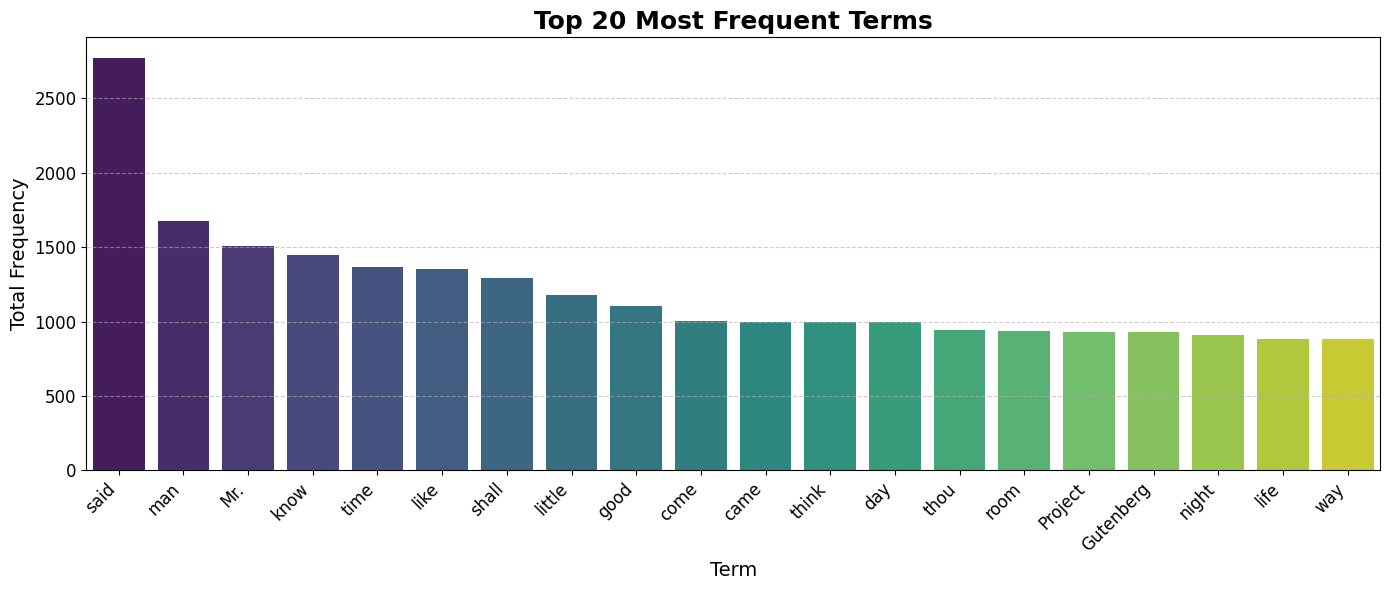

In [25]:
import seaborn as sns

import matplotlib.pyplot as plt

top_n = 20
term_totals = df.sum(axis=0).sort_values(ascending=False)[:top_n]

plt.figure(figsize=(14, 6))
sns.barplot(
    x=term_totals.index,
    y=term_totals.values,
    palette="viridis"
)
plt.title(f"Top {top_n} Most Frequent Terms", fontsize=18, weight="bold")
plt.ylabel("Total Frequency", fontsize=14)
plt.xlabel("Term", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

We can even use Lexos' own `cloud` module to generate a word cloud of the most frequent terms in our corpus. In this visualization, each word's size is proportional to its overall frequency in the corpus—the larger the word appears, the more often it occurs.

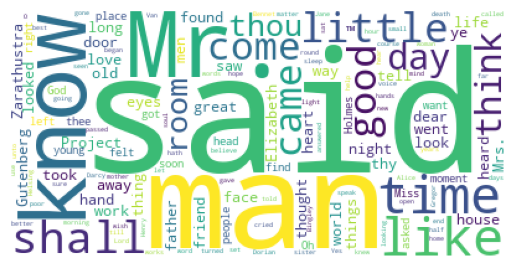

In [15]:
from lexos.visualization.cloud import wordcloud

# Make a word cloud of the most frequent terms in your corpus
wordcloud(dtm)

In addition to these basic visualizations, the Lexos API provides built-in tools for more advanced visualizations. For more details and examples, refer to the [Visualization page](#) or the relevant Lexos API documentation. These tools help you explore and present your text data more effectively.

## 7. Running the Test Suite

Also included in this repository is a comprehensive test suite of the dtm module. It can be run with the following command in your terminal, assuming you are using `uv` as well:
```bash
uv run pytest tests/dtm
```

The test suite was found to have 100% coverage. This can be verified with the following commands:
```bash
uv run pytest --cov=src/lexos/dtm --cov-report=html tests/dtm
```
